# Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

# Data Collection

In [3]:
# Loading the dataset from .csv format to pandas dataframe
exercise_dataset = pd.read_csv("/content/unzipped_data/exercise.csv")

In [8]:
# Loading the dataset from .csv format to pandas dataframe
calories_dataset = pd.read_csv("/content/unzipped_data/calories.csv")

# Data Preprocessing

In [9]:
#printing the 1st five rows of the dataset
exercise_dataset.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [10]:
#printing the 1st five rows of the dataset
calories_dataset.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


#### Cocateniation of the datasets

In [11]:
# Combining the exercise_dataset with the calories dataset
cal_dataset = pd.concat([exercise_dataset, calories_dataset["Calories"] ], axis=1)

In [12]:
#printing the 1st five rows of the dataset
cal_dataset.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [14]:
#printing the last five rows of the dataset
cal_dataset.tail()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5,98.0


In [13]:
# checking the number of rows and columns in the dataset
cal_dataset.shape

(15000, 9)

In [15]:
# finding the detail about the dataset
cal_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [16]:
# Finding the missing Values
cal_dataset.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [17]:
# Finding the statistical measures about the dataset
cal_dataset.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Data Visualization

In [18]:
sns.set()

<Axes: xlabel='count', ylabel='Gender'>

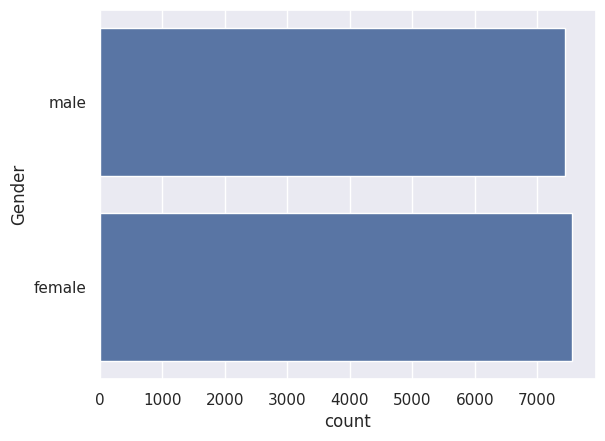

In [20]:
# Finding the distribution of the Gender column - how many males or females
sns.countplot(cal_dataset['Gender'])

/tmp/ipykernel_542/3715439505.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cal_dataset['Age'])


<Axes: xlabel='Age', ylabel='Density'>

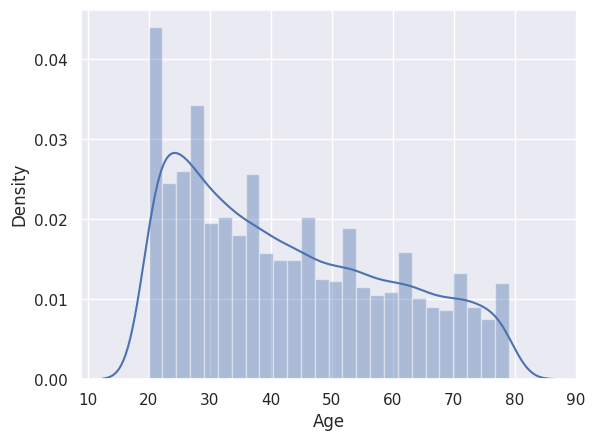

In [22]:
# finding the distribution  of Age Column
sns.distplot(cal_dataset['Age'])

/tmp/ipykernel_542/3446704056.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cal_dataset['Height'])


<Axes: xlabel='Height', ylabel='Density'>

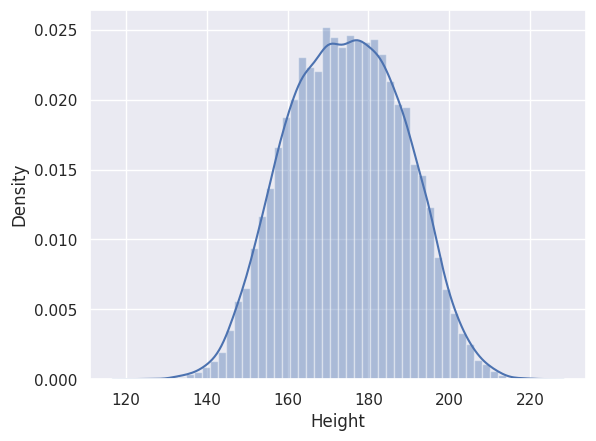

In [23]:
# finding the distribution  of Height Column
sns.distplot(cal_dataset['Height'])

/tmp/ipykernel_542/1524494539.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cal_dataset['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

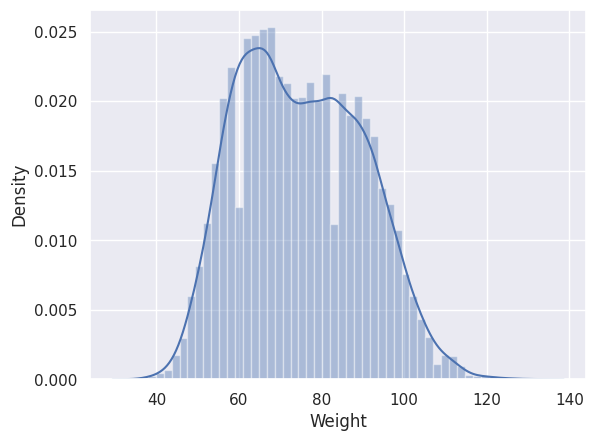

In [26]:
# finding the distribution  of weight Column
sns.distplot(cal_dataset['Weight'])

## Finding the Correlation in the dataset

In [28]:
# Dropping the 'Gender' column as it's categorical and cannot be used for direct numerical correlation
cal_dataset_numeric = cal_dataset.drop('Gender', axis=1)
correlation = cal_dataset_numeric.corr()


<Axes: >

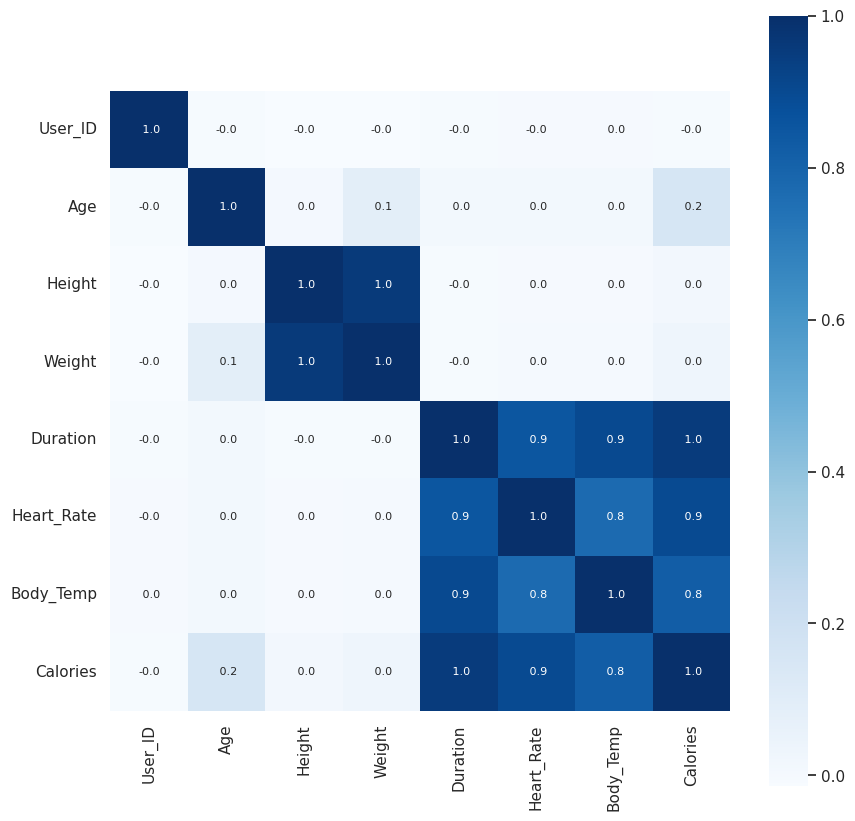

In [30]:
#Constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation , cbar=True , square=True , fmt= ' .1f' , annot=True , cmap= 'Blues', annot_kws= {'size' : 8} )

### Understanding the correlation between values
                                               HeartRate , Body_Tempture , Duration are highly correlated with the Calories -- Positive Correlation

### Converting the Categorical column Gender to Numerical values 0,1
1. Male -- 0
2. Female--1


In [32]:
# replacing the gender's with 0 , 1
cal_dataset.replace({"Gender" : {'male' : 0 , 'female' : 1}} , inplace=True)

/tmp/ipykernel_542/3046040972.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cal_dataset.replace({"Gender" : {'male' : 0 , 'female' : 1}} , inplace=True)


In [33]:
# checking the updation
cal_dataset

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0


# Split the data into Target and Features
1. Target -- Calories column
2. Features -- other columns

In [36]:
# features
X = cal_dataset.drop(columns=['User_ID' , 'Calories'] , axis=1)

In [35]:
# Target
y = cal_dataset['Calories']

In [39]:
# printing the Features
X

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,68,190.0,94.0,29.0,105.0,40.8
1,1,20,166.0,60.0,14.0,94.0,40.3
2,0,69,179.0,79.0,5.0,88.0,38.7
3,1,34,179.0,71.0,13.0,100.0,40.5
4,1,27,154.0,58.0,10.0,81.0,39.8
...,...,...,...,...,...,...,...
14995,1,20,193.0,86.0,11.0,92.0,40.4
14996,1,27,165.0,65.0,6.0,85.0,39.2
14997,1,43,159.0,58.0,16.0,90.0,40.1
14998,0,78,193.0,97.0,2.0,84.0,38.3


In [40]:
# printing the Target
y

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0
...,...
14995,45.0
14996,23.0
14997,75.0
14998,11.0


# Splitting the data into Training or Testing data

In [41]:
# Splitting the data into train or test
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.3, random_state=42)

In [42]:
#Print the shape of X
X.shape

(15000, 7)

In [43]:
#Print the shape of X_train
X_train.shape

(10500, 7)

In [44]:
#Print the shape of X_test
X_test.shape

(4500, 7)

# Model Creation

In [45]:
# Model calling that already imported
xgbr_model = XGBRegressor()

In [46]:
#fitting the training data into model for training
xgbr_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# Model Evalution

### Model evalution on the testing prediction

In [49]:
# predicting on testing data
testing_data_prediction = xgbr_model.predict(X_test)

In [50]:
# printing the prediction
print(testing_data_prediction)

[171.13277  192.90846   50.323795 ...  29.489561 195.85133  138.3994  ]


# Comparing the actual value vs predicted values

### Mean Absolute error

In [51]:
# Finding the mean_absolute_error value
mae = metrics.mean_absolute_error(y_test, testing_data_prediction)
print("Mean Absolute Error = " , mae)

Mean Absolute Error =  1.506805005186134


# **Building a Predictive System**

In [62]:
"""# Building a Predictive System"""

def predict_calories(gender, age, height, weight, duration, heart_rate, body_temp):
    """
    Predicts calories burnt based on input features.

    Parameters:
    gender     : 'male' or 'female' (or 0/1 directly)
    age        : age in years
    height     : height in cm
    weight     : weight in kg
    duration   : exercise duration in minutes
    heart_rate : heart rate during exercise
    body_temp  : body temperature during exercise

    Returns:
    Predicted calories burnt (float)
    """

    # Convert gender to numeric if given as string
    if isinstance(gender, str):
        gender = 0 if gender.lower() == 'male' else 1

    # Creating the input array in the same column order as X
    input_data = (gender, age, height, weight, duration, heart_rate, body_temp)

    # Changing input_data to a numpy array
    input_data_as_numpy_array = np.asarray(input_data)

    # Reshaping the array as we are predicting for one instance
    input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

    # Making the prediction
    prediction = xgbr_model.predict(input_data_reshaped)

    return prediction[0]


# Example usage
input_gender = 'male'
input_age = 25
input_height = 175
input_weight = 70
input_duration = 20
input_heart_rate = 105
input_body_temp = 40.5

predicted_calories = predict_calories(
    input_gender, input_age, input_height,
    input_weight, input_duration, input_heart_rate, input_body_temp
)

print(f"Predicted Calories Burnt = {predicted_calories:.2f}")

Predicted Calories Burnt = 106.77
